![header](https://i.imgur.com/I4ake6d.jpg)


# COPERNICUS MARINE SERVICE : Arctic Ocean

<div style="text-align: right"><i> Lesson 3 of 3 - Copernicus Marine Toolbox </i></div>

***
<center><h1> Shrinking sea ice and Atlantic Water: working with data remotely with open_dataset and read_dataframe </h1></center>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Run" and select "Run All Above Selected Cell".<br>
<br>
**General Note 3**: Exercises are shown in yellow boxes. Write your answer in the empty cell below each exercise. If you are stuck, a solution can be loaded from the `_solved` folder.<br>
***

# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Set up Python](#2.-Set-up-Python)
    - [2.1 Required Python modules](#2.1-Required-Python-modules)
    - [2.2 Checking the environment](#2.2-Checking-the-environment)
- [3. Working with data without downloading files](#3.-Working-with-data-without-downloading-files)
    - [3.1 The Help Center and the Data Store](#3.1-The-Help-Center-and-the-Data-Store)
    - [3.2 Four ways to access the data](#3.2-Four-ways-to-access-the-data)
    - [3.3 The sea ice reanalysis](#3.3-The-sea-ice-reanalysis)
    - [3.4 The Arctic in situ observations](#3.4-The-Arctic-in-situ-observations)
- [4. Logging in](#4.-Logging-in)
- [5. Sea ice extent with open_dataset](#5.-Sea-ice-extent-with-open_dataset)
    - [5.1 Opening a dataset remotely](#5.1-Opening-a-dataset-remotely)
    - [5.2 Selecting data before loading them](#5.2-Selecting-data-before-loading-them)
    - [5.3 Computing the sea ice extent](#5.3-Computing-the-sea-ice-extent)
    - [5.4 Saving the results](#5.4-Saving-the-results)
- [6. Ocean temperature with read_dataframe](#6.-Ocean-temperature-with-read_dataframe)
    - [6.1 Reading in situ data remotely](#6.1-Reading-in-situ-data-remotely)
    - [6.2 Building a temperature time series](#6.2-Building-a-temperature-time-series)
    - [6.3 Saving the results](#6.3-Saving-the-results)
- [7. Exercises to go further](#7.-Exercises-to-go-further)
- [8. Conclusion](#8.-Conclusion)

---
# 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

The Arctic is warming about four times faster than the global average, and its sea ice is the most visible sign of this change. Each September, at the end of the melt season, the ice cover reaches its minimum, and this minimum has become much smaller over the last decades. To measure this change, we need to look at **decades** of data, not at a single day.

Part of the heat that melts the ice comes from the ocean itself. Warm **Atlantic Water** flows north along the west coast of Svalbard and enters its fjords, such as **Isfjorden**, the largest fjord of the archipelago. Moorings installed at the mouth of Isfjorden by the University Centre in Svalbard (UNIS) record its temperature all year round.

Computing a 30-year time series or exploring thousands of measurements would require downloading many files with `get` or `subset`. In this notebook, we will instead use two functions of the Copernicus Marine Toolbox that let you **work with the data directly in Python**, without saving any file first.

| | |
| :--- | :--- |
| **Objective** | Learn how to open gridded data remotely with `open_dataset` and read observations as a table with `read_dataframe`, and how to compute time series from them. |
| **Main questions** | How fast is the Arctic losing its summer sea ice? How does the temperature of the water entering Isfjorden vary through the year? |
| **Expected outcomes** | You will be able to open a dataset without downloading it, select the data you need before loading them, compute a sea ice extent time series and its trend, read and filter in situ observations with pandas, build a temperature time series, and save your results. |
| **Duration** | About 1 hour |
| **Prerequisites** | A free [Copernicus Marine account](https://data.marine.copernicus.eu/register) and basic Python knowledge. Knowing the `get` and `subset` functions (lessons 1 and 2) helps, but is not required. |

---
# 2. Set up Python

[Go back to the "Table of contents"](#Table-of-contents)

## 2.1 Required Python modules

[Go back to the "Table of contents"](#Table-of-contents)

The Jupyter Notebook must be set up with all the necessary tools from the Jupyter Notebook ecosystem. Here is the list of the modules we will be using in this notebook.

| Module name | Description |
| :---: | :---|
| **copernicusmarine** | The [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) gives access to the Copernicus Marine catalogue and data from Python or from the command line. |
| **xarray** | [Xarray](https://docs.xarray.dev/en/stable/) is a very user-friendly library to manipulate multi-dimensional data such as NetCDF files within Python. It introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays. |
| **dask** | [Dask](https://docs.dask.org/en/stable/) lets xarray work on data that are too large to fit in memory, by loading them piece by piece, only when they are needed. |
| **pandas** | [Pandas](https://pandas.pydata.org/docs/) is a powerful package to manage data tables. |
| **numpy** | [NumPy](https://numpy.org/) is the fundamental package for scientific computing with Python. |
| **matplotlib** | [Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces high quality figures. |
| **cartopy** | [Cartopy](https://scitools.org.uk/cartopy/docs/latest/) is a library for plotting maps and geospatial data in Python. |
| **pathlib** | [Pathlib](https://docs.python.org/3/library/pathlib.html) handles file paths in the same way on every operating system. |

We also import three helpers stored in `utils/sea_ice.py`, specific to the sea ice product we will use: its map projection, a function computing the area of its grid cells, and a function drawing maps. You can open the file to see how they work.

In [1]:
# To avoid warning messages
import warnings
warnings.filterwarnings("ignore")

# Import libraries
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from utils.sea_ice import NEXTSIM_PROJECTION, grid_cell_area_km2, plot_nextsim_map

## 2.2 Checking the environment

[Go back to the "Table of contents"](#Table-of-contents)

Let's check the versions of the main packages. This notebook was written for **version 2.5.0** of the Copernicus Marine Toolbox: if your version is older, see the [installation guide](https://help.marine.copernicus.eu/en/articles/7970514-copernicus-marine-toolbox-installation) to update it.

In [2]:
for package in ["copernicusmarine", "xarray", "dask", "pandas", "numpy", "matplotlib", "cartopy"]:
    print(f"{package:<18} {version(package)}")

copernicusmarine   2.5.0b0
xarray             2026.7.0
dask               2026.8.0
pandas             3.0.5
numpy              2.5.3
matplotlib         3.11.1
cartopy            0.25.0


We also create a folder for the results we will save at the end of each part:

In [3]:
data_directory = Path("data")
data_directory.mkdir(exist_ok=True)
print(f"Results will be saved to: {data_directory.resolve()}")

Results will be saved to: /homelocal/gkoenig/Downloads/Training_Toolbox/data


## 2.3 Copernicus Marine Toolbox
[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) is a library that gives access to the Copernicus Marine data from Python code or from the command line.

To import it, we use:

In [4]:
import copernicusmarine

### 2.3.1 Logging in

[Go back to the "Table of contents"](#Table-of-contents)

First, we import the Toolbox and log in. The **login** function asks for the username and password of your Copernicus Marine account, and saves them in a configuration file so that you do not need to enter them again. If you have already logged in during a previous notebook, it simply checks your existing credentials.

If you do not have an account yet, you can create one for free on the [registration page](https://data.marine.copernicus.eu/register).

In [5]:
copernicusmarine.login()

INFO - 2026-10-08T14:34:11Z - Using existing credentials from /homelocal/gkoenig/.copernicusmarine/.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


True

---
# 3. Working with data without downloading files

[Go back to the "Table of contents"](#Table-of-contents)

## 3.1 The Help Center and the Data Store

[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Help Center](https://help.marine.copernicus.eu/) answers most questions about the Copernicus Marine products and tools. Throughout this notebook, the 📖 boxes point to the articles that go deeper into each topic. A good place to start is [How to access and download Copernicus Marine data](https://help.marine.copernicus.eu/en/articles/16733110-how-to-access-and-download-copernicus-marine-data).

The [Copernicus Marine Data Store](https://data.marine.copernicus.eu/products) lists all the products of the service. You can find a product with the filters ("Variables", "Areas", "Time range", or "Advanced" for more criteria) or by typing its name or ID in the search bar. Each product page has a **Description**, a **Data access** section listing its datasets and their IDs, and a **Documentation** section with the Product User Manual (PUM) and the Quality Information Document (QUID).

> 📖 **Learn more in the Help Center:** [Introduction to the Data Store](https://help.marine.copernicus.eu/en/articles/6722477-introduction-to-the-copernicus-marine-data-store) · [How to search for a product](https://help.marine.copernicus.eu/en/articles/4425061-how-to-search-for-a-product-within-the-copernicus-marine-data-store) · [Products, datasets and their identifiers](https://help.marine.copernicus.eu/en/articles/4703373-differences-between-copernicus-marine-products-and-datasets-and-their-identifiers)

## 3.2 Four ways to access the data

[Go back to the "Table of contents"](#Table-of-contents)

The Copernicus Marine Toolbox offers four functions to access the data. They do not return the same thing, and each one fits a different need:

| Function | What it returns | Saves a file? | Best for |
| :---: | :--- | :---: | :--- |
| `get` | The **original files** of the producer | Yes | Whole files, archives, the producer's own software |
| `subset` | A **selection** (area, period, depths, variables) | Yes | Extracting a region or a period to keep it on disk |
| `open_dataset` | An **xarray dataset**, opened remotely | No | Exploring and computing on gridded data, even very large ones |
| `read_dataframe` | A **pandas table**, loaded in memory | No | Observations, point time series, small selections |

`open_dataset` and `read_dataframe` take the same selection options as `subset` (variables, area, period, depths), but return the data **directly in Python**. With `open_dataset`, the data are only transferred when a computation or a plot needs them: this is called **lazy loading**. If you want to keep a copy, you can still save the result with `.to_netcdf()` or `.to_csv()`.

> 📖 **Learn more in the Help Center:** [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely) · [Toolbox data access services](https://help.marine.copernicus.eu/en/articles/7969584-copernicus-marine-toolbox-data-access-services) · [Differences between original files and ARCO data](https://help.marine.copernicus.eu/en/articles/8656000-differences-between-original-producer-files-and-arco-data)

## 3.3 The sea ice reanalysis

[Go back to the "Table of contents"](#Table-of-contents)

For the sea ice, we use the **Arctic Ocean Sea Ice Reanalysis**, produced by the Nansen Environmental and Remote Sensing Center (NERSC, Norway) with the neXtSIM sea ice model. A **reanalysis** reconstructs the past: the model is run over several decades, and regularly corrected with satellite observations of the sea ice concentration (and, in winter since 2010, of its thickness). The result is a consistent record of the Arctic sea ice since 1993.

The product provides the data on a regular latitude and longitude grid, and on its **original grid**: a polar stereographic map of the Arctic with 3 km cells. We use the original grid, which is smaller and better suited to the Arctic.

| Parameter | Value |
| :---: | :---|
| **Product ID** | [ARCTIC_MULTIYEAR_PHY_ICE_002_016](https://data.marine.copernicus.eu/product/ARCTIC_MULTIYEAR_PHY_ICE_002_016/description) |
| **Dataset ID** | cmems_mod_arc_phy_my_nextsim_P1M-m (monthly means), part "originalGrid" |
| **Source** | Numerical model with data assimilation (reanalysis) |
| **Spatial resolution** | 3 km, polar stereographic grid |
| **Temporal resolution** | Monthly means (a daily dataset is also available) |
| **Temporal coverage** | From 1993 to a few months ago |
| **Variable used** | siconc (sea ice concentration: fraction of each cell covered by ice, from 0 to 1) |
| **DOI** | [10.48670/mds-00336](https://doi.org/10.48670/mds-00336) |

| <img src="https://mdl-metadata.s3.waw3-1.cloudferro.com/metadata/thumbnails/ARCTIC_MULTIYEAR_PHY_ICE_002_016.jpg" width="400"> |
|:--:|
| Arctic Ocean Sea Ice Reanalysis. - From the [Copernicus Marine Data Store](https://data.marine.copernicus.eu/product/ARCTIC_MULTIYEAR_PHY_ICE_002_016/description) |

**For information on how to use the product, please consult the User Manual:** [Product User Manual (PUM)](https://documentation.marine.copernicus.eu/PUM/CMEMS-ARC-PUM-002-016.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://documentation.marine.copernicus.eu/QUID/CMEMS-ARC-QUID-002-016.pdf)

## 3.4 The Arctic in situ observations

[Go back to the "Table of contents"](#Table-of-contents)

For the ocean temperature, we use the **Arctic Ocean In Situ Near Real Time Observations**, distributed by the Copernicus Marine In Situ Thematic Assembly Centre (INSTAC). It gathers the measurements of many types of platforms (moorings, ships, profiling floats, gliders, drifting buoys...) in a single, quality-controlled collection. Unlike gridded products, these data are **sparse**: each measurement has its own platform, position, depth and time.

| Parameter | Value |
| :---: | :---|
| **Product ID** | [INSITU_ARC_PHYBGCWAV_DISCRETE_MYNRT_013_031](https://data.marine.copernicus.eu/product/INSITU_ARC_PHYBGCWAV_DISCRETE_MYNRT_013_031/description) |
| **Dataset ID** | cmems_obs-ins_arc_phybgcwav_mynrt_na_irr, part "history" |
| **Source** | In situ observations |
| **Spatial coverage** | Arctic Ocean |
| **Temporal resolution** | Irregular: depends on each platform |
| **Variable used** | TEMP (sea water temperature, °C) |
| **DOI** | [10.48670/moi-00031](https://doi.org/10.48670/moi-00031) |

| <img src="https://mdl-metadata.s3.waw3-1.cloudferro.com/metadata/thumbnails/INSITU_ARC_PHYBGCWAV_DISCRETE_MYNRT_013_031.jpg" width="400"> |
|:--:|
| Arctic Ocean In Situ Near Real Time Observations. - From the [Copernicus Marine Data Store](https://data.marine.copernicus.eu/product/INSITU_ARC_PHYBGCWAV_DISCRETE_MYNRT_013_031/description) |

Each in situ dataset has several **parts**: "history" contains the full record of each platform, while "latest" and "monthly" contain the most recent data only. You can also explore the platforms on a map with the [In Situ TAC dashboard](https://marineinsitu.eu/dashboard/).

**For information on how to use the product, please consult the User Manual:** [Product User Manual (PUM)](https://documentation.marine.copernicus.eu/PUM/CMEMS-INS-PUM-013-030-036.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://documentation.marine.copernicus.eu/QUID/CMEMS-INS-QUID-013-030-036.pdf)

> 📖 **Learn more in the Help Center:** [What is in the PUM?](https://help.marine.copernicus.eu/en/articles/4425095-what-kind-of-information-can-be-found-in-the-pum) · [What is in the QUID?](https://help.marine.copernicus.eu/en/articles/6588555-what-kind-of-information-can-be-found-in-the-quid) · [How to cite Copernicus Marine products](https://help.marine.copernicus.eu/en/articles/4444611-how-to-cite-copernicus-marine-products-and-services)

> 📖 **Learn more in the Help Center:** [Toolbox credentials configuration](https://help.marine.copernicus.eu/en/articles/8185007-copernicus-marine-toolbox-credentials-configuration)

---
# 5. Sea ice extent with open_dataset

[Go back to the "Table of contents"](#Table-of-contents)

## 5.1 Opening a dataset remotely

[Go back to the "Table of contents"](#Table-of-contents)

The `open_dataset` function takes the same arguments as `subset`. Here, we only select the variable `siconc` and the original grid of the dataset with `dataset_part`, and keep the whole area and the whole period:

In [31]:
sea_ice_dataset_id = "cmems_mod_arc_phy_my_nextsim_P1M-m"

sea_ice = copernicusmarine.open_dataset(
    dataset_id=sea_ice_dataset_id,
    dataset_part="originalGrid",
    variables=["siconc"],
    service="arco-geo-series"
)
sea_ice

WARNING - 2026-10-09T07:27:17Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T07:27:17Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T07:27:17Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-09T07:27:17Z - Selected dataset version: "202411"
INFO - 2026-10-09T07:27:17Z - Selected dataset part: "originalGrid"


<xarray.Dataset> Size: 19GB
Dimensions:    (time: 401, y: 2367, x: 2467)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2026-05-01
  * y          (y) float64 19kB -4.3e+06 -4.297e+06 ... 2.795e+06 2.798e+06
  * x          (x) float64 20kB -3.6e+06 -3.597e+06 ... 3.795e+06 3.798e+06
    latitude   (y, x) float64 47MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    longitude  (y, x) float64 47MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Data variables:
    siconc     (time, y, x) float64 19GB dask.array<chunksize=(50, 1024, 1024), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.6
    contact:                   servicedesk.cmems@mercator-ocean.eu
    credit:                    E.U. Copernicus Marine Service Information (CM...
    field_date:                2023-12-16
    institution:               NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    references:                https://marine.copernicus.eu/
    source:                    neXtSIM model fields
    title:                     Arctic sea ice reanalysis
    copernicusmarine_version:  2.5.0b0

The dataset opened in a few seconds, although it covers more than 30 years. This is because **nothing has been downloaded yet**: only the description of the dataset (its dimensions, coordinates and metadata) has been read. Click on the 📄 icon next to `siconc` to see its attributes, and on the database icon to see how the data are split into pieces (chunks).

Let's check how much data this represents:

In [32]:
first_month = pd.Timestamp(sea_ice.time.values[0])
last_month = pd.Timestamp(sea_ice.time.values[-1])

print(f"Number of months: {sea_ice.time.size}, from {first_month:%B %Y} to {last_month:%B %Y}")
print(f"Grid size: {sea_ice.sizes['y']} x {sea_ice.sizes['x']} cells")
print(f"Size of siconc if it were downloaded: {sea_ice['siconc'].nbytes / 1e9:.1f} GB")

Number of months: 401, from January 1993 to May 2026
Grid size: 2367 x 2467 cells
Size of siconc if it were downloaded: 18.7 GB


Several gigabytes, for a single variable. With `open_dataset`, we will only transfer the small part we actually need.

<div class="alert alert-block alert-warning">

**Exercise 1**

The same product also contains **daily** data, in the dataset `cmems_mod_arc_phy_my_nextsim_P1D-m`. Open it remotely, still on its original grid and for the variable `siconc`.

How many time steps does it contain, and how large would it be if you downloaded it?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Copy the `open_dataset` cell above, change the dataset ID, and store the result in a new variable, for example `daily_sea_ice`.
</details>

In [8]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [34]:
# %load _solved/ARCTBX-03-open-read_exercise-1.py
# Open the daily dataset remotely: nothing is downloaded yet
daily_sea_ice = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_arc_phy_my_nextsim_P1D-m",
    dataset_part="originalGrid",
    variables=["siconc"],
)

print(f"Number of days: {daily_sea_ice.time.size}")
print(f"Size if it were downloaded: {daily_sea_ice['siconc'].nbytes / 1e9:.0f} GB")
print(f"That is {daily_sea_ice['siconc'].nbytes / sea_ice['siconc'].nbytes:.0f} times more than the monthly dataset")


WARNING - 2026-10-09T07:27:32Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T07:27:32Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T07:27:32Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-09T07:27:32Z - Selected dataset version: "202411"
INFO - 2026-10-09T07:27:32Z - Selected dataset part: "originalGrid"


Number of days: 12204
Size if it were downloaded: 570 GB
That is 30 times more than the monthly dataset


## 5.2 Selecting data before loading them

[Go back to the "Table of contents"](#Table-of-contents)

Since the ice reaches its minimum in September, we select the September of each year. Xarray can read the month of each date with `.dt.month`, and keep only the months equal to 9. This selection is also lazy: still nothing is downloaded.

In [35]:
september = sea_ice["siconc"].sel(time=sea_ice.time.dt.month == 9)

print(f"Number of Septembers: {september.time.size}")
print(f"From {pd.Timestamp(september.time.values[0]):%Y} to {pd.Timestamp(september.time.values[-1]):%Y}")

Number of Septembers: 33
From 1993 to 2025


Let's map the first and the last September of the dataset. The data are transferred at this moment, but only for these two months:

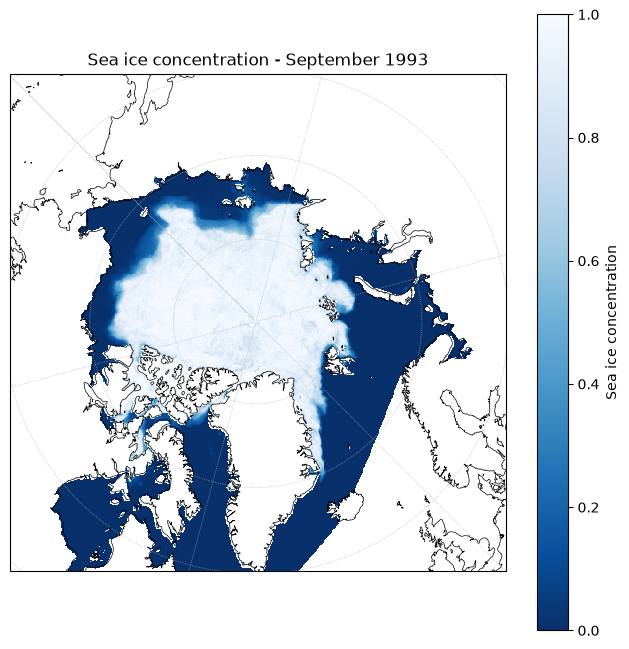

In [36]:
first_september = sea_ice["siconc"].sel(time="1993-09-01")

plot_nextsim_map(
    first_september,
    "Sea ice concentration - September 1993",
    cmap="Blues_r", vmin=0, vmax=1,
    cbar_kwargs={"label": "Sea ice concentration"},
)
plt.show()

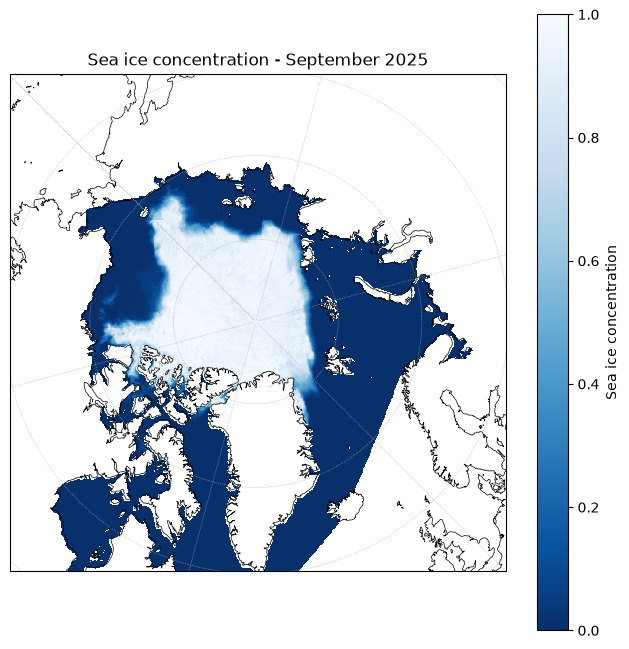

In [37]:
last_september = sea_ice["siconc"].sel(time="2025-09-01")

plot_nextsim_map(
    last_september,
    "Sea ice concentration - September 2025",
    cmap="Blues_r", vmin=0, vmax=1,
    cbar_kwargs={"label": "Sea ice concentration"},
)
plt.show()

Compare the two maps: the area covered by ice in September has clearly shrunk, especially along the coasts of Siberia and Alaska.

<div class="alert alert-block alert-warning">

**Exercise 2**

Do the same for the winter maximum: map the sea ice concentration of the **first and last March** of the dataset.

Does the winter ice cover change as much as the summer one?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Replace `9` by `3` in the selection, and reuse the map cell above.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

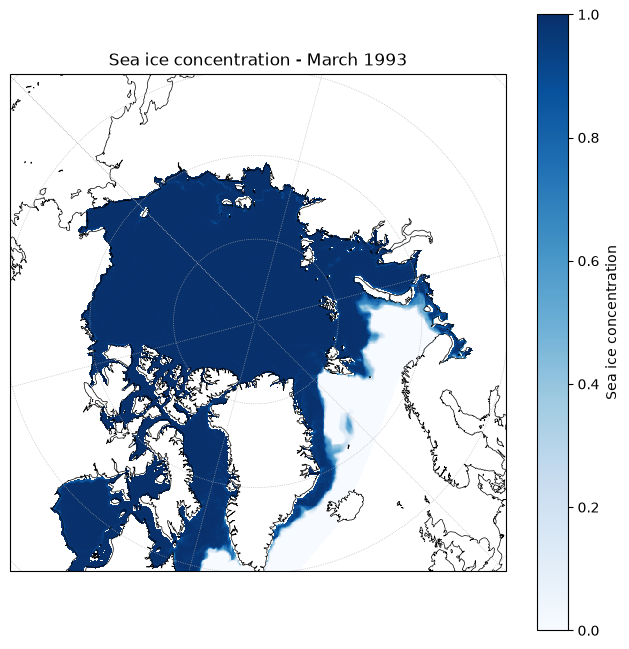

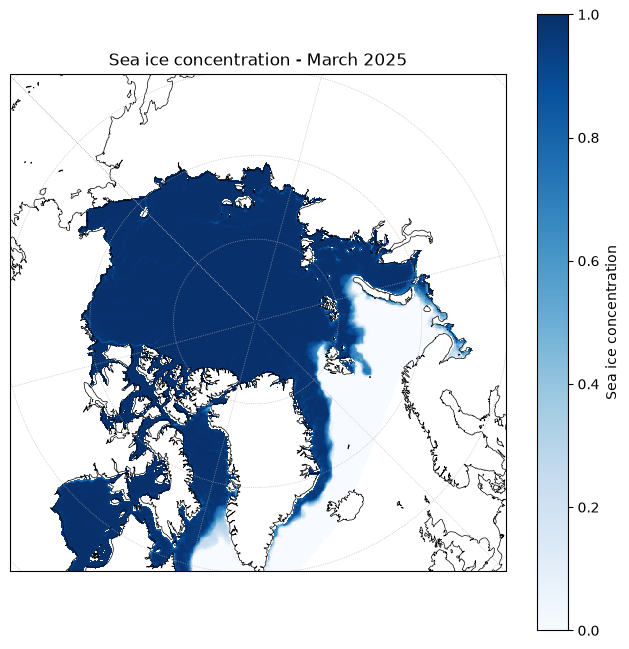

In [42]:
# %load _solved/ARCTBX-03-open-read_exercise-2.py
# Select the months of March, then the first and last March of the dataset
first_march= sea_ice["siconc"].sel(time="1993-03-01")

plot_nextsim_map(
    first_march,
    "Sea ice concentration - March 1993",
    cmap="Blues", vmin=0, vmax=1,
    cbar_kwargs={"label": "Sea ice concentration"},
)
plt.show()

last_march= sea_ice["siconc"].sel(time="2025-03-01")

plot_nextsim_map(
    last_march,
    "Sea ice concentration - March 2025",
    cmap="Blues", vmin=0, vmax=1,
    cbar_kwargs={"label": "Sea ice concentration"},
)
plt.show()


## 5.3 Computing the sea ice extent

[Go back to the "Table of contents"](#Table-of-contents)

Maps are useful, but to measure the change we need a number. The **sea ice extent** is the total area of the ocean where the ice concentration is **at least 15%**. It is the standard indicator used to follow the Arctic sea ice.

To compute it, we need the area of each grid cell. On a polar stereographic map, the cells are exactly 3 km x 3 km at the pole, but cover a bit less area further south. The function `grid_cell_area_km2` takes this into account. As a check, the areas should range from about 6 km² at the edges of the grid to 9 km² at the pole:

In [43]:
cell_area = grid_cell_area_km2(sea_ice)

print(f"Cell area: from {float(cell_area.min()):.2f} km² to {float(cell_area.max()):.2f} km²")

Cell area: from 6.23 km² to 9.00 km²


The extent is then a simple xarray computation, written in one line:

- `september >= 0.15` is True where there is enough ice
- `cell_area.where(...)` keeps the area of these cells only
- `.sum(dim=["y", "x"])` adds up all the cells, for each September
- dividing by 1,000,000 gives the result in **million km²**

Until now, xarray has only prepared the computation. `.compute()` runs it: this is when the data of the 30+ Septembers are transferred, which can take a minute or two.

In [44]:
september_extent = (cell_area.where(september >= 0.15).sum(dim=["y", "x"]) / 1e6).compute()
september_extent

<xarray.DataArray 'cell_area' (time: 33)> Size: 264B
array([6.81413163, 7.4592938 , 6.36212371, 8.11094256, 7.05518158,
       6.97696865, 6.77057156, 6.69438964, 7.00320683, 6.35954552,
       6.54742468, 6.31961921, 5.8472522 , 6.29605008, 4.63176573,
       5.17235378, 5.72720834, 5.43162941, 4.96027757, 3.95700738,
       5.61715933, 5.69423054, 5.25267065, 5.24862657, 5.2484134 ,
       5.28438792, 4.74859323, 4.4203113 , 5.48866808, 5.44258463,
       4.74986252, 4.61238372, 4.80060232])
Coordinates:
  * time     (time) datetime64[ns] 264B 1993-09-01 1994-09-01 ... 2025-09-01
Attributes:
    units:      km2
    long_name:  Area of the grid cell

Let's plot the time series, with a linear trend computed with NumPy:

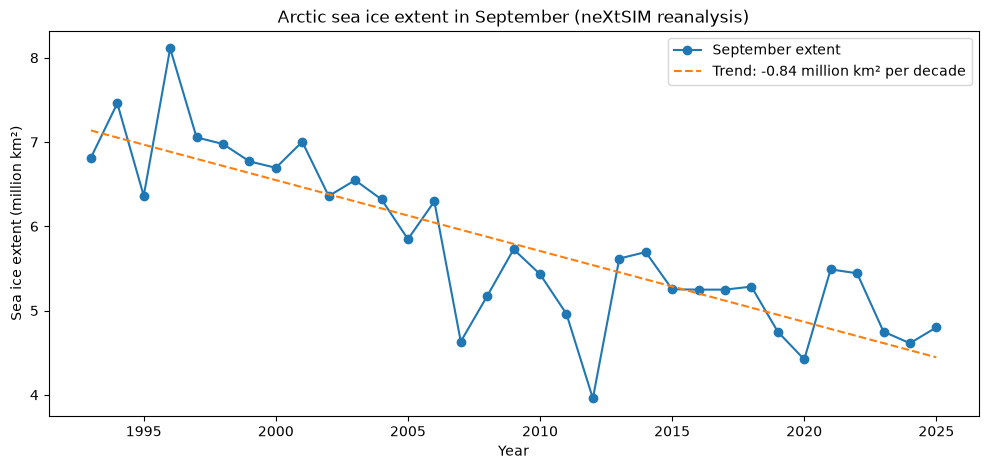

Mean September extent: 5.79 million km²
Trend: -0.84 million km² per decade (-14.5% of the mean per decade)


In [45]:
years = september_extent.time.dt.year.values
slope, intercept = np.polyfit(years, september_extent.values, 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, september_extent, marker="o", label="September extent")
ax.plot(years, slope * years + intercept, "--", label=f"Trend: {10 * slope:+.2f} million km² per decade")
ax.set_xlabel("Year")
ax.set_ylabel("Sea ice extent (million km²)")
ax.set_title("Arctic sea ice extent in September (neXtSIM reanalysis)")
ax.legend()
plt.show()

print(f"Mean September extent: {float(september_extent.mean()):.2f} million km²")
print(f"Trend: {10 * slope:+.2f} million km² per decade ({100 * 10 * slope / float(september_extent.mean()):+.1f}% of the mean per decade)")

The September extent shows large differences from one year to the next, driven by the weather of each summer, but also a clear downward trend. Compare your result with the 2025 minimum measured by satellites: about 4.6 million km² on 10 September 2025. The values are close but not identical, as we use monthly means and a model, not daily satellite maps.

<div class="alert alert-block alert-warning">

**Exercise 3**

Compute the sea ice extent of **every March** and its trend, and plot it together with the September extent.

Which season loses more ice, in million km² per decade? And relative to its mean extent?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Select the months of March as in exercise 2, then reuse the extent and trend cells. Use new variable names (for example `march_extent` and `march_slope`) so that you can still plot the September results.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

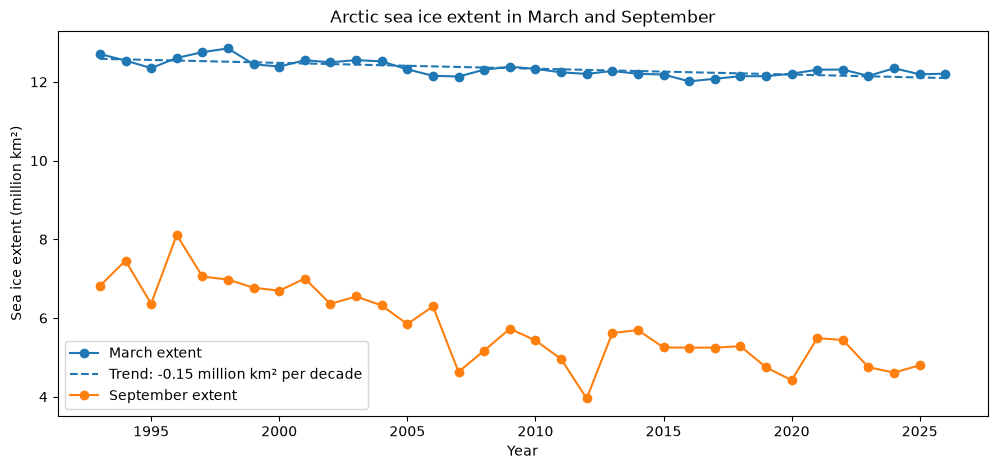

March trend:     -0.15 million km² per decade (-1.2% of the mean per decade)
September trend: -0.84 million km² per decade (-14.5% of the mean per decade)


In [47]:
# %load _solved/ARCTBX-03-open-read_exercise-3.py
# March sea ice extent: area of the cells with at least 15% of ice
march = sea_ice["siconc"].sel(time=sea_ice.time.dt.month == 3)
march_extent = (cell_area.where(march >= 0.15).sum(dim=["y", "x"]) / 1e6).compute()

march_years = march_extent.time.dt.year.values
march_slope, march_intercept = np.polyfit(march_years, march_extent.values, 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(march_years, march_extent, marker="o", color="tab:blue", label="March extent")
ax.plot(march_years, march_slope * march_years + march_intercept, "--", color="tab:blue",
        label=f"Trend: {10 * march_slope:+.2f} million km² per decade")
ax.plot(years, september_extent, marker="o", color="tab:orange", label="September extent")
ax.set_xlabel("Year")
ax.set_ylabel("Sea ice extent (million km²)")
ax.set_title("Arctic sea ice extent in March and September")
ax.legend()
plt.show()

print(f"March trend:     {10 * march_slope:+.2f} million km² per decade "
      f"({100 * 10 * march_slope / float(march_extent.mean()):+.1f}% of the mean per decade)")
print(f"September trend: {10 * slope:+.2f} million km² per decade "
      f"({100 * 10 * slope / float(september_extent.mean()):+.1f}% of the mean per decade)")


## 5.4 Saving the results

[Go back to the "Table of contents"](#Table-of-contents)

`open_dataset` does not save anything on disk. To keep a result, for example to reuse it in another notebook, we save it with `.to_netcdf()`. Our time series is tiny, so this is instantaneous:

In [48]:
september_extent.name = "sea_ice_extent"
september_extent.attrs = {
    "units": "million km2",
    "long_name": "Arctic sea ice extent (concentration of at least 15%), September monthly mean",
    "source": "ARCTIC_MULTIYEAR_PHY_ICE_002_016 (cmems_mod_arc_phy_my_nextsim_P1M-m, original grid)",
}

extent_file = data_directory / "september_sea_ice_extent.nc"
september_extent.to_netcdf(extent_file)
print(f"Saved to {extent_file} ({extent_file.stat().st_size / 1e3:.0f} kB)")

Saved to data/september_sea_ice_extent.nc (10 kB)


You can also save a selection of the dataset itself, for example `last_september.to_netcdf(...)`. In that case, the data are transferred when the file is written, so keep your selection small.

> 📖 **Learn more in the Help Center:** [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely) · [How to open and visualize Copernicus Marine data using Python](https://help.marine.copernicus.eu/en/articles/4854800-how-to-open-and-visualize-copernicus-marine-data-using-python)

---
# 6. Ocean temperature with read_dataframe

[Go back to the "Table of contents"](#Table-of-contents)

## 6.1 Reading in situ data remotely

[Go back to the "Table of contents"](#Table-of-contents)

In situ observations do not fit well in a grid: they are better represented as a **table**, with one row per measurement. This is what `read_dataframe` returns, as a pandas DataFrame. Unlike `open_dataset`, it loads the data **in memory** right away, so the selection should stay reasonably small.

We select the temperature measured at the **mouth of Isfjorden**, from the surface to 200 m, over three years. For in situ datasets, `dataset_part="history"` selects the full record of the platforms:

In [49]:
insitu_dataset_id = "cmems_obs-ins_arc_phybgcwav_mynrt_na_irr"

temperature_data = copernicusmarine.read_dataframe(
    dataset_id=insitu_dataset_id,
    dataset_part="history",
    variables=["TEMP"],
    minimum_longitude=12.0,
    maximum_longitude=15.5,
    minimum_latitude=77.8,
    maximum_latitude=78.4,
    minimum_depth=0,
    maximum_depth=200,
    start_datetime="2021-01-01",
    end_datetime="2023-12-31",
)

WARNING - 2026-10-09T13:30:17Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T13:30:17Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-09T13:30:17Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-09T13:30:18Z - Selected dataset version: "202311"
INFO - 2026-10-09T13:30:18Z - Selected dataset part: "history"
100%|██████████| [00:14<00:00]


Let's check what we received. A DataFrame is a table: `len` gives its number of rows, and `.head()` shows the first ones:

In [50]:
if temperature_data.empty:
    print("No data found: try a larger area or another period.")
else:
    print(f"Number of measurements: {len(temperature_data)}")
    print(f"Columns: {list(temperature_data.columns)}")

temperature_data.head()

Number of measurements: 98520
Columns: ['variable', 'platform_id', 'platform_type', 'time', 'longitude', 'latitude', 'depth', 'pressure', 'is_depth_from_producer', 'value', 'value_qc', 'institution', 'doi', 'product_doi']


,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,value,value_qc,institution,doi,product_doi
0,TEMP,1801779,DB,2023-08-29T01:03:00Z,12.72626,78.12658,-0.0,None,1,-0.05,1,Alfred Wegener Institute Helmholtz Centre for ...,https://doi.org/10.13155/59938 https://doi.org...,https://doi.org/10.48670/moi-00031
1,TEMP,4601820,DB,2021-09-26T04:00:00Z,12.00600,77.95100,-0.0,None,1,3.86,1,Scripps Institution of Oceanography,https://doi.org/10.13155/59938 https://doi.org...,https://doi.org/10.48670/moi-00031
2,TEMP,4601820,DB,2021-09-26T05:00:00Z,12.01980,77.95240,-0.0,None,1,3.86,1,Scripps Institution of Oceanography,https://doi.org/10.13155/59938 https://doi.org...,https://doi.org/10.48670/moi-00031
3,TEMP,4601820,DB,2021-09-26T06:00:00Z,12.03660,77.95380,-0.0,None,1,3.82,1,Scripps Institution of Oceanography,https://doi.org/10.13155/59938 https://doi.org...,https://doi.org/10.48670/moi-00031
4,TEMP,4601820,DB,2021-09-26T07:00:00Z,12.05540,77.95400,-0.0,None,1,3.80,1,Scripps Institution of Oceanography,https://doi.org/10.13155/59938 https://doi.org...,https://doi.org/10.48670/moi-00031


Each row is one measurement. The main columns are:

- `platform_id` and `platform_type`: the platform that made the measurement. The type is a two-letter code, for example **MO** for a mooring (fixed station), **CT** for a CTD profile, **PF** for a profiling float or **GL** for a glider (the full list is in the PUM of the product)
- `time`, `longitude`, `latitude` and `depth`: where and when it was made
- `value`: the measured temperature, in °C
- `value_qc`: its **quality flag**. **1** means good data, 2 probably good data, and higher values are doubtful, bad or missing data

We convert the `time` column to dates, so that pandas can work with it:

In [51]:
temperature_data["time"] = pd.to_datetime(temperature_data["time"])
print(f"From {temperature_data['time'].min():%d %B %Y} to {temperature_data['time'].max():%d %B %Y}")

From 31 January 2021 to 02 December 2023


<div class="alert alert-block alert-warning">

**Exercise 4**

How many **different platforms** measured the temperature in this area, and of **which types**? How many measurements does each type of platform provide?

**Bonus:** plot the positions of the platforms, with one colour per type.
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

`temperature_data.groupby("platform_type")` groups the rows by type. Then `["platform_id"].nunique()` counts the different platforms and `.size()` counts the rows.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

               number_of_platforms  number_of_measurements
platform_type                                             
CT                               7                   53334
DB                               8                     608
FB                               1                   15789
GL                               1                   28694
TS                               1                      95


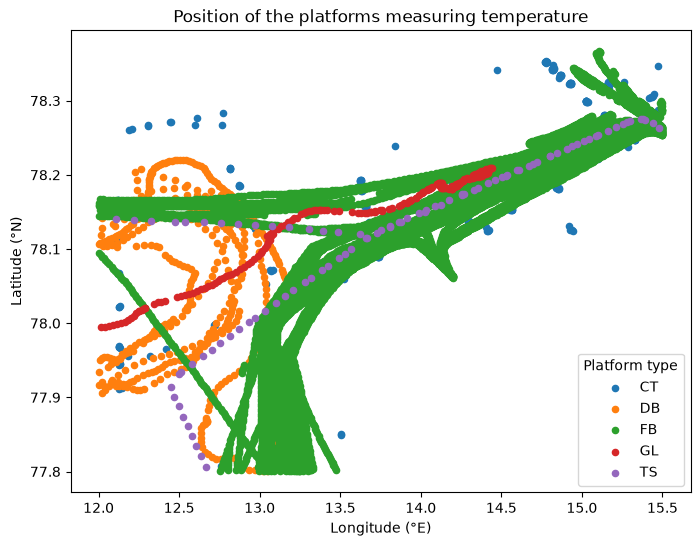

In [ ]:
# %load _solved/ARCTBX-03-open-read_exercise-4.py


> 📖 **Learn more in the Help Center:** [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely) · [Filter in situ original files using index files](https://help.marine.copernicus.eu/en/articles/9630028-filter-and-download-insitu-original-files-using-index-files-with-python)

## 6.2 Building a temperature time series

[Go back to the "Table of contents"](#Table-of-contents)

To follow the temperature through the year, we need a platform that stays at the same place: a **mooring** (type MO). Let's count the measurements of each platform:

In [54]:
measurements_per_platform = (
    temperature_data.groupby(["platform_id", "platform_type"]).size().sort_values(ascending=False)
)
measurements_per_platform

platform_id  platform_type
58HJ         CT               35270
6801614      GL               28694
LAOU7        FB               15789
LIER         CT               11226
LF7363       CT                2735
9690949      CT                1674
58GS         CT                1263
58US         CT                1020
6501689      DB                 258
58JH         CT                 146
FMNB         TS                  95
6501545      DB                  79
6501548      DB                  64
6501687      DB                  60
4601820      DB                  50
6501671      DB                  49
6501547      DB                  47
1801779      DB                   1
dtype: int64

We keep the mooring with the most measurements:

In [55]:
moorings = temperature_data[temperature_data["platform_type"] == "MO"]
if moorings.empty:
    raise ValueError("No mooring in this selection: enlarge the area or change the period in section 6.1.")

chosen_platform = moorings["platform_id"].value_counts().index[0]
platform_data = moorings[moorings["platform_id"] == chosen_platform]

print(f"Chosen platform: {chosen_platform} ({len(platform_data)} measurements)")
print(f"Position: {platform_data['latitude'].median():.2f}°N, {platform_data['longitude'].median():.2f}°E")

ValueError: No mooring in this selection: enlarge the area or change the period in section 6.1.

Before using the data, we check their **quality flags** and keep only the good data (flag 1):

In [ ]:
print("Number of measurements per quality flag:")
print(platform_data["value_qc"].value_counts())

good_data = platform_data[platform_data["value_qc"] == 1]
print(f"Good data kept: {len(good_data)} of {len(platform_data)} measurements")

A mooring carries several instruments at different depths. Let's see which depths are measured most often, rounded to the nearest metre:

In [ ]:
good_data["depth"].round().value_counts().head(10)

We keep the instrument with the most measurements, and build its time series. The `set_index("time")` method uses the dates as the index of the table, which lets pandas compute **daily** and **monthly means** with `.resample()`:

In [ ]:
sensor_depth = good_data["depth"].round().value_counts().index[0]
sensor_data = good_data[good_data["depth"].round() == sensor_depth]

temperature_series = sensor_data.set_index("time")["value"].sort_index()
daily_temperature = temperature_series.resample("D").mean()
monthly_temperature = temperature_series.resample("MS").mean()

print(f"Depth of the instrument: {sensor_depth:.0f} m, {len(temperature_series)} measurements")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(temperature_series.index, temperature_series, color="lightgrey", linewidth=0.5, label="All measurements")
ax.plot(daily_temperature.index, daily_temperature, linewidth=1, label="Daily mean")
ax.plot(monthly_temperature.index, monthly_temperature, marker="o", label="Monthly mean")
ax.set_ylabel("Sea water temperature (°C)")
ax.set_title(f"Temperature at {sensor_depth:.0f} m, mooring {chosen_platform}")
ax.legend()
plt.show()

print(f"Warmest month: {monthly_temperature.idxmax():%B %Y} ({monthly_temperature.max():.1f}°C)")
print(f"Coldest month: {monthly_temperature.idxmin():%B %Y} ({monthly_temperature.min():.1f}°C)")

The temperature follows a seasonal cycle, but it is not only driven by the sun: at depth, warm pulses often correspond to Atlantic Water entering the fjord, carried by the West Spitsbergen Current that we studied in lesson 2. Gaps in the curve usually mean that the mooring was recovered for maintenance, or that the data are not available yet.

<div class="alert alert-block alert-warning">

**Exercise 5**

A mooring measures at several depths. Take the **second most measured depth** of the same mooring, compute its monthly mean temperature, and plot it together with the first one.

At which depth is the seasonal cycle the largest? Can you explain why?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

`.value_counts().index[1]` gives the second most common value. Then reuse the cells above with new variable names, and plot both monthly series on the same figure.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [ ]:
# %load _solved/ARCTBX-03-open-read_exercise-5.py

## 6.3 Saving the results

[Go back to the "Table of contents"](#Table-of-contents)

`read_dataframe` does not save anything on disk either. To keep the data, we save the table with `.to_csv()`, which can be opened in any spreadsheet software:

In [ ]:
csv_file = data_directory / "isfjorden_temperature.csv"
sensor_data.to_csv(csv_file, index=False)
print(f"Saved {len(sensor_data)} measurements to {csv_file} ({csv_file.stat().st_size / 1e3:.0f} kB)")

> 📖 **Learn more in the Help Center:** [Download data for multiple points from a CSV with Python](https://help.marine.copernicus.eu/en/articles/7970637-download-data-for-multiple-points-from-a-csv-with-python)

---
# 7. Exercises to go further

[Go back to the "Table of contents"](#Table-of-contents)

<div class="alert alert-block alert-info">

Here is a set of exercises to go further. There are two levels, depending on how much Python code you need to write. If you need help, do not hesitate to look at the [Help Center](https://help.marine.copernicus.eu/) or to contact the service desk: **[servicedesk.cmems@mercator-ocean.eu](mailto:servicedesk.cmems@mercator-ocean.eu)**!

**Beginners**:

- Change the threshold of the sea ice extent from 15% to 50%. How does it change the values and the trend?
- The sea ice dataset also contains the ice thickness, `sithick`. Open it, and map it for the first and last September of the dataset.
- Read the **salinity** (`PSAL`) of the in situ dataset at the mouth of Isfjorden, and draw its time series for the same mooring.

**Intermediate**:

- Compute the **sea ice volume** in September: for each cell, multiply the area, the concentration and the thickness, then add up all the cells. Does the volume decrease faster than the extent?
- `read_dataframe` also works with **gridded** datasets: it then returns a table with one row per grid point and date. Use it on the [Arctic Ocean Physics Reanalysis](https://data.marine.copernicus.eu/product/ARCTIC_MULTIYEAR_PHY_002_003/description) (dataset `cmems_mod_arc_phy_my_topaz4_P1M`, variable `thetao`) at the position and depth of the mooring, and compare the model with the observations.
- Do the same with the satellite surface temperature of the product [SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016](https://data.marine.copernicus.eu/product/SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016/description) (dataset `cmems_obs_si_arc_phy_my_L4-DMIOI_P1D-m`, variable `analysed_st`, in kelvin), and compare it with the shallowest instrument of the mooring.

</div>

---
# 8. Conclusion

[Go back to the "Table of contents"](#Table-of-contents)

<div class="alert alert-block alert-success">
    <b>Congratulations !!</b><br>

And thank you for your attention! :)

In this notebook, you have learned to:

* Open a dataset remotely with `open_dataset`, and check its size without downloading it
* Select data lazily with xarray, and transfer only what a plot or a computation needs
* Compute the sea ice extent and its trend over three decades
* Read in situ observations as a table with `read_dataframe`, and filter them by platform, quality flag and depth
* Build daily and monthly time series with pandas
* Save your results with `.to_netcdf()` and `.to_csv()`

Together with `get` and `subset`, you now know the four ways to access Copernicus Marine data with the Toolbox. As a reminder: use `get` for original files, `subset` to save a selection on disk, `open_dataset` to explore and compute on gridded data, and `read_dataframe` for observations and point time series.

To go further, here are some Help Center articles:

* [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely)
* [Toolbox API - Subset](https://help.marine.copernicus.eu/en/articles/8283072-copernicus-marine-toolbox-api-subset) and [Toolbox API - Get original files](https://help.marine.copernicus.eu/en/articles/8286883-copernicus-marine-toolbox-api-get-original-files)
* [How to download data for specific depth levels in Python](https://help.marine.copernicus.eu/en/articles/9521812-how-to-download-data-for-specific-depth-levels-in-python)
* [How to open and visualize Zarr format data](https://help.marine.copernicus.eu/en/articles/8077952-how-to-open-and-visualize-zarr-format-data)
* [Using the Copernicus Marine Toolbox in operational workflows](https://help.marine.copernicus.eu/en/articles/8684964-using-the-copernicus-marine-toolbox-in-operational-workflows)
* [Toolbox FAQ](https://help.marine.copernicus.eu/en/articles/8630590-copernicus-marine-toolbox-faq) and [troubleshooting](https://help.marine.copernicus.eu/en/articles/8632322-copernicus-marine-toolbox-troubleshoots)
* [Copernicus Marine community and trainings](https://help.marine.copernicus.eu/en/collections/3740164-copernicus-marine-community-and-trainings)

This training course is over but we'd love to hear from you about how we could improve it (topics, tools, storytelling, format, speed etc). If you have any question, do not hesitate to contact us at [servicedesk.cmems@mercator-ocean.eu](mailto:servicedesk.cmems@mercator-ocean.eu)!
</div>